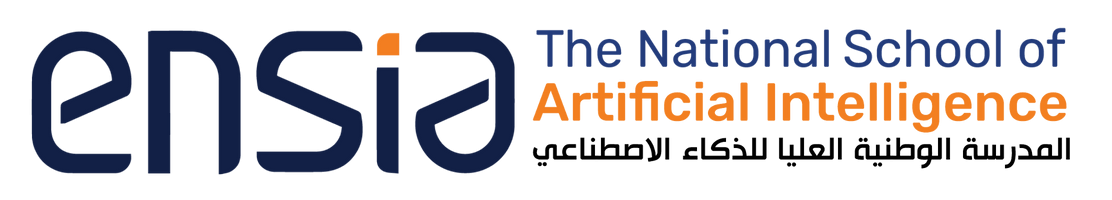

# **Error Based Learning PART II: LOGISTIC REGRESSION**

# **Overview**

> Logistic Regression is a statistical model used for binary classification problems. Despite its name, logistic regression is a linear model used for classification rather than regression. It predicts the probability of a binary outcome (either 0 or 1), based on one or more input features.

> The model is based on the logistic function, also known as the sigmoid function, which is used to map the output of a linear equation to a probability value between 0 and 1. The core of logistic regression involves fitting a linear decision boundary to the data, and then using the logistic function to convert the output of the linear combination into a probability.


> In this lab, You will work with the following variants:

> ✅**Binary Logistic Regression** – a linear model used for classification rather than regression. models the probability of a binary outcome (e.g., yes/no) using a logistic function.

> ✅**Polynomial Logistic Regression** – Extend logistic regression by creating polynomial features to capture non-linear relationships in the data, transforming a linear model into a non-linear one.

> ✅**Multinomial Logistic Regression** – Extends the binary model to predict among three or more unordered categories (e.g., product types A, B, C) by estimating relative probabilities.

> Through hands-on implementation, you will gain insights into how these models work, how they differ, and how they can be leveraged for decision-making.

---
# **PART I: Binary Logistic Regression**
---

## Logistic Function (Sigmoid)

The logistic function, or sigmoid function, is given by:

$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

Where:
- $z$ is the linear combination of input features and weights: $z = w^T X + b$
- $w$ are the weights (parameters) of the model.
- $X$ are the input features.
- $b$ is the bias term.

The sigmoid function outputs values between 0 and 1, which are interpreted as probabilities of belonging to a particular class (class 1 in binary classification).

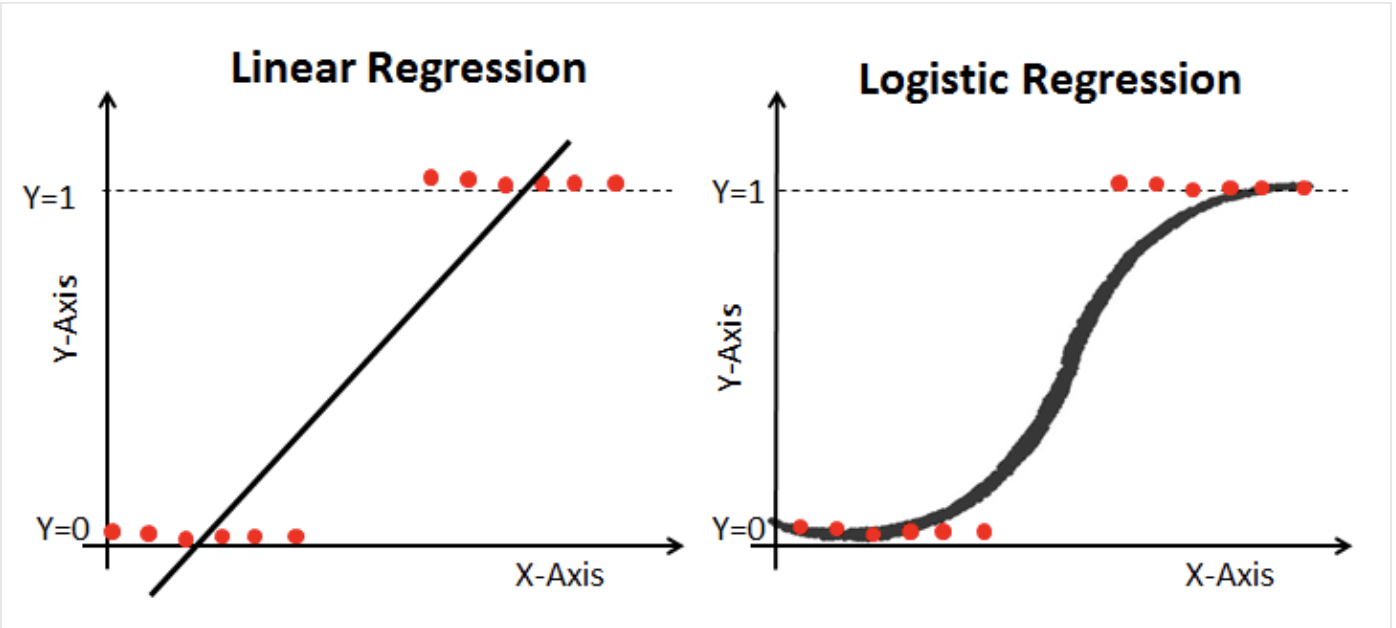

## Cost Function (Binary Cross-Entropy Loss)

The cost function used in logistic regression is the **binary cross-entropy loss** (also known as log loss). This loss function measures the difference between the predicted probability and the actual class labels.

The formula for binary cross-entropy loss is:


$$ J(w, b) = -\frac{1}{m} \sum_{i=1}^{m} \left( y^{(i)} \log(h_{\theta}(x^{(i)})) + (1 - y^{(i)}) \log(1 - h_{\theta}(x^{(i)})) \right) $$

Where:
- $m$ is the number of training examples.
- $y^{(i)}$ is the true label of the $i^{(th)}$ sample (0 or 1).
- $h_{\theta}(x^{(i)})$ is the predicted probability for the $i^{(th)}$ sample.


The goal is to minimize this loss function using optimization techniques like gradient descent.

## Gradient Descent Optimization

To minimize the binary cross-entropy loss function, logistic regression uses **gradient descent**. This iterative method updates the model parameters (weights and bias) by computing the gradients of the cost function with respect to each parameter and adjusting them in the opposite direction of the gradient.

The gradient of the cost function with respect to the weights is computed as:


$$ \frac{\partial J(w, b)}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} (h_{\theta}(x^{(i)}) - y^{(i)}) x^{(i)} $$

And for the bias:


$$ \frac{\partial J(w, b)}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (h_{\theta}(x^{(i)}) - y^{(i)}) $$

These gradients are used to update the weights and bias:


$$ w := w - \alpha \frac{\partial J(w, b)}{\partial w} $$

$$ b := b - \alpha \frac{\partial J(w, b)}{\partial b}$$

Where:
- $\alpha$ is the learning rate, a hyperparameter that controls the size of the step taken in each iteration.

## Model Prediction

Once the model is trained, the weights and bias are fixed. To make a prediction for a new input $X$, we compute the linear combination $z = w^T X + b$ and then apply the sigmoid function to get the predicted probability:


$$ y_{\hat{}} = \sigma(w^T X + b) $$

If the predicted probability is greater than 0.5, the class label is predicted as 1; otherwise, it is predicted as 0.

## Summary

Logistic Regression involves the following steps:
1. Initialize the weights and bias.
2. For each iteration, compute the predicted probabilities using the sigmoid function.
3. Calculate the loss using binary cross-entropy.
4. Update the weights and bias using gradient descent.
5. Repeat until the loss converges or the maximum number of iterations is reached.

### Benefits of Logistic Regression
- Simple and interpretable model.
- Can handle both continuous and categorical input variables.
- Computationally efficient.

### Limitations
- Assumes a linear relationship between the input features and the log-odds of the outcome.
- Can be sensitive to outliers.
- Not suitable for complex problems with non-linear relationships.


In [158]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.metrics import confusion_matrix,  ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

## Utility Functions

In [159]:
def load_linear_data_3D():
  # Generate linearly separable data
  np.random.seed(0)
  x0 = np.random.normal(loc=2, scale=1, size=(50, 2))
  x1 = np.random.normal(loc=5, scale=1, size=(50, 2))

  # Add some noise to make the classes not perfectly separable
  x0[48:] += 4
  x1[:2] -= 3

  # Generate third feature
  x0_third_feature = np.random.normal(loc=1, scale=0.5, size=(50,))
  x1_third_feature = np.random.normal(loc=3, scale=0.5, size=(50,))

  # Combine features into 3D points
  x0 = np.hstack((x0, x0_third_feature.reshape(-1, 1)))
  x1 = np.hstack((x1, x1_third_feature.reshape(-1, 1)))

  # Create DataFrame
  df_x0 = pd.DataFrame(x0, columns=['feature1', 'feature2', 'feature3'])
  df_x1 = pd.DataFrame(x1, columns=['feature1', 'feature2', 'feature3'])

  # Add target column
  df_x0['target'] = 0
  df_x1['target'] = 1

  # Concatenate x1 and x2 DataFrames and shuffle
  df = pd.concat([df_x0, df_x1], ignore_index=True)
  df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle rows

  # return the DataFrame
  return df

In [160]:
def standardize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    # Replace zeros in std with 1 to avoid division by zero
    std[std == 0] = 1
    return (X - mean) / std

In [161]:
# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z)) # TODO: Implement the sigmoid function σ(z) = 1 / (1 + e^(-z)) which transforms any input to a probability between 0 and 1

In [162]:
def plot_scatter(X, y, markers=None, colors=None,
                          title='Scatter Plot', xlabel='Feature 1', ylabel='Feature 2',
                          legend_fontsize=16, title_fontsize=20, label_fontsize=16):
    """
    Plots a scatter plot of the data points X against the target y,
    with different classes represented by different markers and colors.

    Parameters:
    - X: NumPy array of shape (n_samples, 2) containing the features.
    - y: NumPy array of shape (n_samples,) containing class labels.
    - markers: (Optional) A dictionary mapping unique class labels to marker styles.
              Example: {0: 'o', 1: 'x'}
    - colors: (Optional) A dictionary mapping unique class labels to colors.
              Example: {0: 'red', 1: 'blue'}
    - title: Title of the plot.
    - xlabel: Label for the x-axis.
    - ylabel: Label for the y-axis.
    - legend_fontsize: Font size for the legend.
    - title_fontsize: Font size for the title.
    - label_fontsize: Font size for the axis labels and ticks.
    """
    # Determine unique classes in y
    # TODO: Determine the unique class labels present in the target y
    unique_classes = np.unique(y)

    # Set default markers if not provided
    if markers is None:
        markers = {c: 'o' for c in unique_classes[:]}

    # Set default colors if not provided
    if colors is None:
        # Default colors for two classes; extend as needed for more classes.
        default_colors = ['red', 'blue', 'green', 'purple', 'orange']
        colors = {c: default_colors[i % len(default_colors)] for i, c in enumerate(unique_classes)}

    # Create figure
    plt.figure(figsize=(12, 8))

    # Plot each class with its corresponding marker and color
    for c in unique_classes:
        # Get indices for class c
        indices = (y == c)
        marker = markers.get(c, 'o')
        color = colors.get(c, 'black')
        # If marker is 'o', we use a hollow circle by setting facecolors='none'
        if marker == 'o':
            plt.scatter(X[indices, 0], X[indices, 1], marker=marker, facecolors='none',
                        edgecolor=color, label=f'Class {c}', s=100, linewidth=2)
        else:
            plt.scatter(X[indices, 0], X[indices, 1], marker=marker, color=color,
                        label=f'Class {c}', s=100, linewidth=2)

    plt.legend(fontsize=legend_fontsize)
    plt.title(title, fontsize=title_fontsize)
    plt.xlabel(xlabel, fontsize=label_fontsize)
    plt.ylabel(ylabel, fontsize=label_fontsize)
    plt.grid(True)
    plt.xticks(fontsize=label_fontsize)
    plt.yticks(fontsize=label_fontsize)
    plt.tight_layout()
    plt.show()

In [163]:
def plot_cost_history(costs):
  fig = px.line(y=costs, title="Cost vs Iteration", template="plotly_dark")
  fig.update_layout(

      title_font_color="#41BEE9",

      xaxis=dict(color="#41BEE9", title="Iterations"),

      yaxis=dict(color="#41BEE9", title="Cost")

  )
  fig.show()

def plot_decision_boundary(model, X, y, resolution=0.05, x_feature=0, y_feature=1):
    """
    Plot the decision boundary for a logistic regression model in a 2D slice of the feature space.

    Parameters:
        model: Model implementing `forward(X)`.
        X: Feature matrix (n_samples, n_features).
        y: True labels.
        resolution: Mesh grid step size.
        x_feature: Index of the x-axis feature.
        y_feature: Index of the y-axis feature.
    """
    n_samples, n_features = X.shape

    # Extract bounds for the two selected features
    x_min, x_max = X[:, x_feature].min() - 1, X[:, x_feature].max() + 1
    y_min, y_max = X[:, y_feature].min() - 1, X[:, y_feature].max() + 1

    # Create mesh grid for the two selected features
    xx, yy = np.meshgrid(np.arange(x_min, x_max),
                         np.arange(y_min, y_max))

    # Initialize full grid with mean values for non-selected features
    grid = np.tile(X.mean(axis=0), (xx.ravel().shape[0], 1))

    # Override the selected x and y features with mesh grid values
    grid[:, x_feature] = xx.ravel()
    grid[:, y_feature] = yy.ravel()

    # Predict probabilities and threshold
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    # Plot decision boundary and data points
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:, x_feature], X[:, y_feature], c=y,
                cmap='coolwarm', edgecolors='k')
    plt.xlabel(f"Feature {x_feature}")
    plt.ylabel(f"Feature {y_feature}")
    plt.title("Decision Boundary")
    plt.show()


In [164]:
from numpy.random import uniform
np.random.seed(42)

class Custom_Logistic_Regression:

    def __init__(self, learning_rate, convergence_tol=1e-6, rate_decay = 0.01):

        # TODO: Initialize the model with learning rate, convergence tolerance, and learning rate decay
        self.learning_rate = learning_rate
        self.rate_decay = rate_decay
        self.convergence_tol = convergence_tol
        self.W = None

    def initialize_parameters(self, n_features):
        self.W = np.random.randn(n_features) * 0.01 # TODO: Initialize weight vector with small random values for better convergence - multiply random normal values by 0.01 to ensure weights start close to zero

    def forward(self, X):
        z = np.dot(X, self.W) # TODO: Compute the linear combination z by taking the dot product of input features X and weights W
        A = self._sigmoid(z) # TODO: Apply the sigmoid activation function to z to get the probability predictions A
        return A

    #Sigmoid method (logistic)
    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x)) # TODO: Implement sigmoid activation function

    def compute_cost(self, predictions):
        # binary cross entropy
        epsilon = 1e-9
        y1 = self.y * np.log(predictions + epsilon) # TODO: Calculate first term: y * log(predictions + epsilon)
        y2 = (1 - self.y) * np.log(1 - predictions + epsilon) # TODO: Calculate second term: (1-y) * log(1 - predictions + epsilon)
        return -np.mean(y1 + y2) # TODO: Return the negative mean of the sum of both terms

    def backward(self, predictions):
        n_samples = self.X.shape[0] # TODO: Get the number of samples in the training set
        dz = predictions - self.y # TODO: Calculate the difference between predictions and actual labels
        dw = (1/n_samples) * np.dot(self.X.T, dz) # TODO: Compute gradients by taking the dot product of the error (dz) and input features (X), then divide by number of samples
        return dw

    def fit(self, X, y, iterations= 1000, plot_cost=True):

        assert isinstance(X, np.ndarray), "X must be a NumPy array"
        assert isinstance(y, np.ndarray), "y must be a NumPy array"
        assert X.shape[0] == y.shape[0], "X and y must have the same number of samples"
        assert iterations > 0, "Iterations must be greater than 0"

        X = (X - np.mean(X, axis=0)) / (np.std(X, axis=0) + 1e-9) # TODO: Standardize the features to have zero mean and unit variance
        X = np.insert(X, 0, 1, axis=1)

        self.X = X # TODO: Store the preprocessed feature X
        self.y = y # TODO: Store the target labels y
        self.initialize_parameters(X.shape[1]) # TODO: Initialize the model parameters W by calling initialize_parameters

        costs = [] # TODO: Create an empty list to store cost history


        initial_lr = self.learning_rate # TODO: Store the initial learning rate for decay calculations

        for i in range(iterations):
            predictions = self.forward(self.X) # TODO: Calculate predictions using forward propagation
            cost = self.compute_cost(predictions) # TODO: Calculate the cost for the current predictions
            delta_error = self.backward(predictions) # TODO: Calculate the gradients using backward propagation

            # Calculate the learning rate for the current iteration
            self.learning_rate = initial_lr / (1 + self.rate_decay * i) # TODO: Update the learning rate using decay formula
            # Update parameters
            self.W = self.W - self.learning_rate * delta_error # TODO: Update the weights using gradient descent

            costs.append(cost) # TODO: Store the current cost for monitoring

            if i % 100 == 0: # Print after each 100 iterations
                print(f'Iteration: {i}, Cost: {cost}')

            if i > 0 and abs(costs[-1] - costs[-2]) < self.convergence_tol:

                print(f'Converged after {i} iterations.')
                break

        if plot_cost:
            plot_cost_history(costs)

    def predict(self, X):
        X = (X - np.mean(X, axis=0)) / (np.std(X, axis=0) + 1e-9) # TODO: Standardize features
        X = np.insert(X, 0, 1, axis=1) # TODO: Add a bias term (column of ones) to the feature matrix
        threshold = 0.5 # TODO: Set the classification threshold (typically 0.5 for binary classification)
        y_predicted = self.forward(X) # TODO: Calculate probability predictions using the forward method
        y_predicted_cls = (y_predicted >= threshold).astype(int) # TODO: Convert probabilities to binary class labels (1 if above threshold, 0 otherwise)
        return np.array(y_predicted_cls)

### Generating linearly seperable data

In [165]:
df = load_linear_data_3D()
X = df.drop('target', axis = 1).values
y = df['target'].values
# Splitting dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
y.shape

(100,)

### Testinig against Scikit Learn's Logistic regression model

Iteration: 0, Cost: 0.6899350961877848
Iteration: 100, Cost: 0.46083841428119887
Iteration: 200, Cost: 0.38645316506961447
Iteration: 300, Cost: 0.3479520875331068
Iteration: 400, Cost: 0.3237092895520702
Iteration: 500, Cost: 0.3067105035170915
Iteration: 600, Cost: 0.2939548252600793
Iteration: 700, Cost: 0.2839270257748908
Iteration: 800, Cost: 0.2757721251268152
Iteration: 900, Cost: 0.26896754776255594


Accuracy:  0.95

Custom Confusion Matrix:


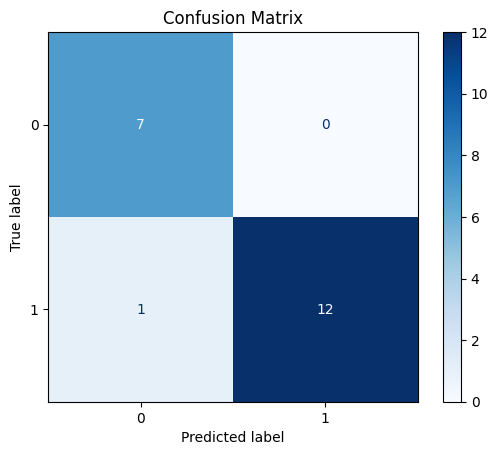

Accuracy:  0.95

Sklearn Confusion Matrix:


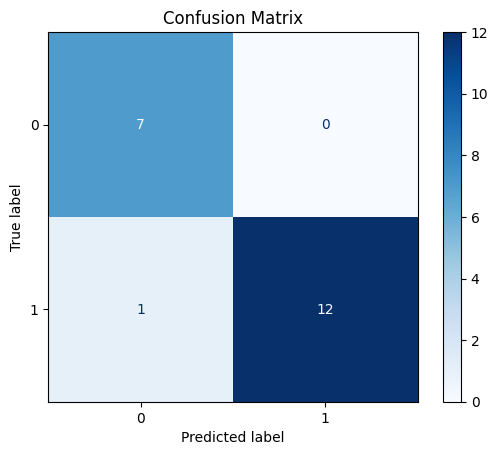

Custom Logistic predictions: [0 0 0 1 1 0 1 1 0 0 0 1 1 1 1 1 0 1 1 1]
Scikit-learn Logistic predictions: [0 0 0 1 1 0 1 1 0 0 0 1 1 1 1 1 0 1 1 1]
Test passed successfully! =D, Custom Logistic predictions match scikit-learn Logistic predictions.


In [166]:
#-----------------------------------------------------------------------------------
#----------------------------Custom Logistic Regression-----------------------------
#-----------------------------------------------------------------------------------
regressor = Custom_Logistic_Regression(learning_rate=0.01)
regressor.fit(X_train, y_train)
predictions = regressor.predict(X_test)
print("Accuracy: ", np.mean(predictions == y_test))

print("\nCustom Confusion Matrix:")
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(np.asarray(y_test), np.asarray(predictions)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

#-----------------------------------------------------------------------------------
#----------------------------Sklearn Logistic Regression----------------------------
#-----------------------------------------------------------------------------------
sklearn_regressor = LogisticRegression(max_iter=1000)
sklearn_regressor.fit(X_train, y_train)
sk_predictions = sklearn_regressor.predict(X_test)
print("Accuracy: ", np.mean(sk_predictions == y_test))

print("\nSklearn Confusion Matrix:")
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(np.asarray(y_test), np.asarray(sk_predictions)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

#-----------------------------------------------------------------------------------
#----------------------------Compare the results------------------------------------
#-----------------------------------------------------------------------------------
print("Custom Logistic predictions:", predictions)
print("Scikit-learn Logistic predictions:", sk_predictions)

# Compare predictions
assert np.array_equal(predictions, sk_predictions), "The predictions do not match!"
print("Test passed successfully! =D, Custom Logistic predictions match scikit-learn Logistic predictions.")


### Plotting the decision plane

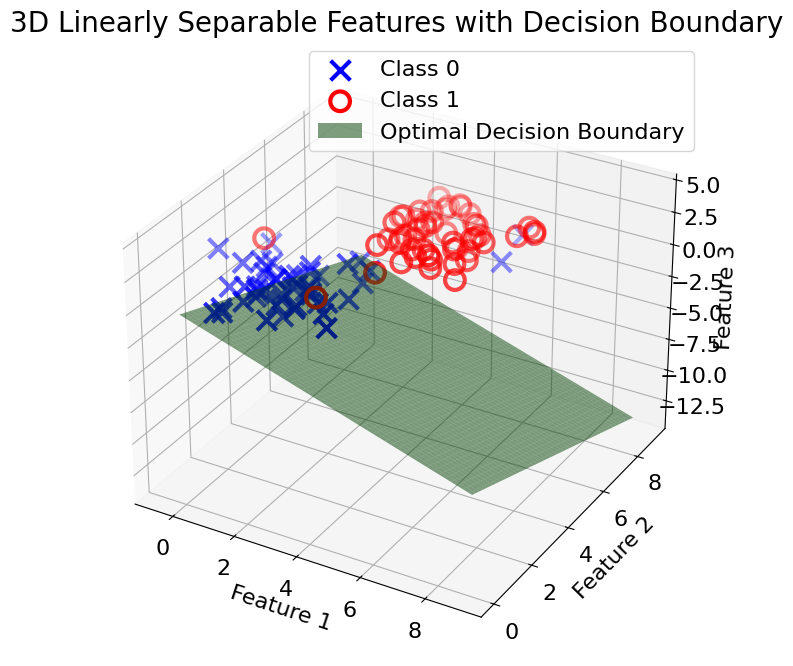

In [167]:
# Plot the data
x0 = X[y == 0]
x1 = X[y == 1]

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x0[:, 0], x0[:, 1], x0[:, 2], marker='x', color='blue', label='Class 0', s=200, linewidth=3)
ax.scatter(x1[:, 0], x1[:, 1], x1[:, 2], s=200, facecolors='none', edgecolors='r', label='Class 1', linewidth=3)

# Plot the separating plane
x_values = np.linspace(0, 9, 100)
y_values = np.linspace(0, 9, 100)
X_plot, Y_plot = np.meshgrid(x_values, y_values)

w = regressor.W
b, w1, w2, w3 = w[0], w[1], w[2], w[3]
#  Solve for z: w0 + w1*x + w2*y + w3*z = 0
Z = -(b + w1 * X_plot + w2 * Y_plot) / w3
ax.plot_surface(X_plot, Y_plot, Z, color='green', alpha=0.5, label='Optimal Decision Boundary')

# Customize plot
ax.set_xlabel('Feature 1', fontsize=16)
ax.set_ylabel('Feature 2', fontsize=16)
ax.set_zlabel('Feature 3', fontsize=16)
ax.set_title('3D Linearly Separable Features with Decision Boundary', fontsize=20)
ax.legend(fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
ax.tick_params(axis='z', which='major', labelsize=16)
# plt.tight_layout()

# Show plot
plt.grid(True)
plt.show()

### Testing with real data

In [168]:
dataset = datasets.load_breast_cancer()
X, y = dataset.data, dataset.target

X, y = dataset.data, dataset.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234
)

#-----------------------------------------------------------------------------------
#----------------------------Custom Logistic Regression-----------------------------
#-----------------------------------------------------------------------------------
regressor = Custom_Logistic_Regression(learning_rate=0.15)
regressor.fit(X_train, y_train)
predictions = regressor.predict(X_test)
print(confusion_matrix(np.asarray(y_test), np.asarray(predictions)))
print("Accuracy: ", np.mean(predictions == y_test))


#-----------------------------------------------------------------------------------
#----------------------------Sklearn Logistic Regression----------------------------
#-----------------------------------------------------------------------------------
sklearn_regressor = LogisticRegression(max_iter=1000)
sklearn_regressor.fit(X_train, y_train)
sk_predictions = sklearn_regressor.predict(X_test)
print(confusion_matrix(np.asarray(y_test), np.asarray(sk_predictions)))
print("Accuracy: ", np.mean(sk_predictions == y_test))

Iteration: 0, Cost: 0.6819201426832693
Iteration: 100, Cost: 0.0863668770483833
Iteration: 200, Cost: 0.07321725818058367
Iteration: 300, Cost: 0.06758852684461275
Iteration: 400, Cost: 0.06427134778606051
Iteration: 500, Cost: 0.06201372864743068
Iteration: 600, Cost: 0.06034473247488523
Iteration: 700, Cost: 0.05904271662412088
Iteration: 800, Cost: 0.057987901415778635
Iteration: 900, Cost: 0.057109127387247674


[[41  4]
 [ 0 69]]
Accuracy:  0.9649122807017544
[[39  6]
 [ 0 69]]
Accuracy:  0.9473684210526315


/home/robot/miniconda3/envs/ensia/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Question: Did you obtain the same results? Why or why not?**
---
**Hint:** *Refer to the sklearn model library—how do these models search for the optimal set of parameters (coefficients)?*

---
# **PART II: Polynomial Logistic Regression**
---

### Generating non linear Data

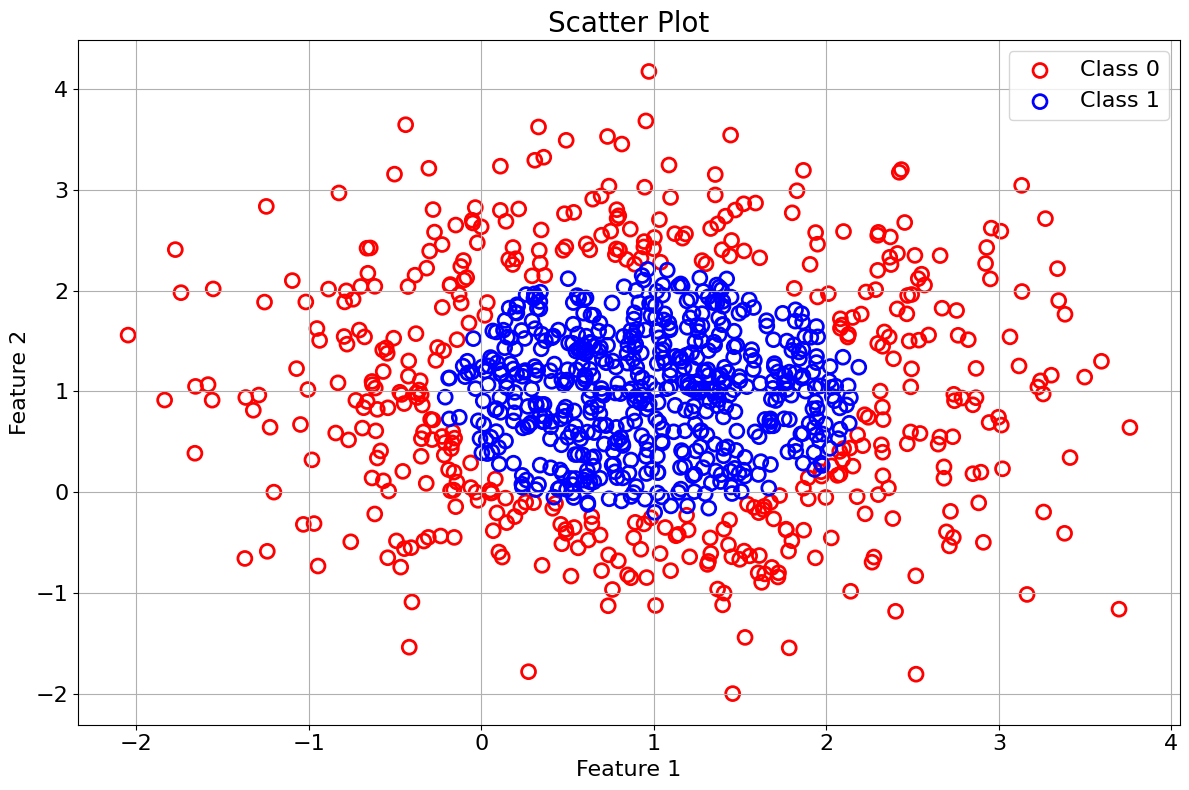

In [169]:
def load_non_liear_data():
  data_points = 1000
  # Generate synthetic data
  np.random.seed(0)
  x1 = np.random.randn(data_points).reshape(data_points, 1)
  x2 = np.random.randn(data_points).reshape(data_points, 1)
  y = ((x1**2 + x2**2) < 1.5).astype(int)
  y = y.reshape(-1)
  x1 += 1     # Moving the center of data points away from origin (Optional)
  x2 += 1     # Moving the center of data points away from origin (Optional)

  # Prepare the data
  X = np.hstack([x1, x2])
  return X, y

X_sampled, y_sampled = load_non_liear_data()

# Display the scatter plot
plot_scatter(X_sampled, y_sampled)

### Using Scikit Learn Logistic Regression model

In [170]:
# Generate the nonlinear decision boundary
def nonlinear_decision_boundary (X, y, model, poly ):

  xx, yy = np.meshgrid(np.linspace(X[:, 0].min(), X[:, 0].max(), 100),
                     np.linspace(X[:, 1].min(), X[:, 1].max(), 100))

  Z = model.predict(poly.transform(np.c_[xx.ravel(), yy.ravel()]))
  Z = Z.reshape(xx.shape)

  # Plot the decision boundary
  plt.contourf(xx, yy, Z, cmap=plt.cm.viridis, alpha=0.8)

  label_colors = {0: "yellow", 1: "blue"}
  colors = [label_colors[label] for label in y]

  plt.scatter(X[:, 0], X[:, 1], c=colors, cmap='coolwarm',  marker='o')

  plt.xlabel('Feature 1')
  plt.ylabel('Feature 2')
  plt.title('Nonlinear Decision Boundary')
  plt.show()


Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        87
           1       1.00      0.99      1.00       113

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200


Confusion Matrix:


/home/robot/miniconda3/envs/ensia/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


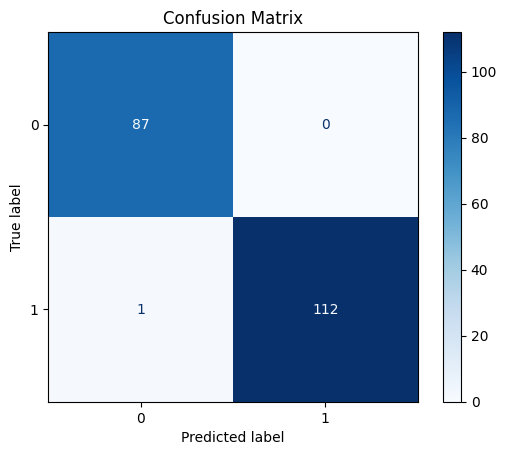

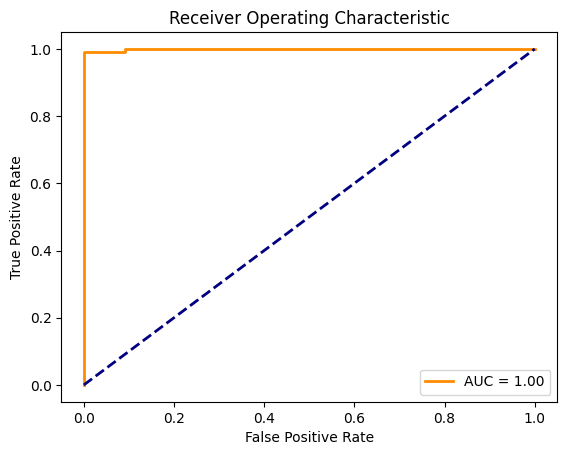

/tmp/ipykernel_37646/1535067637.py:16: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], c=colors, cmap='coolwarm',  marker='o')



Decision Boundary plot:


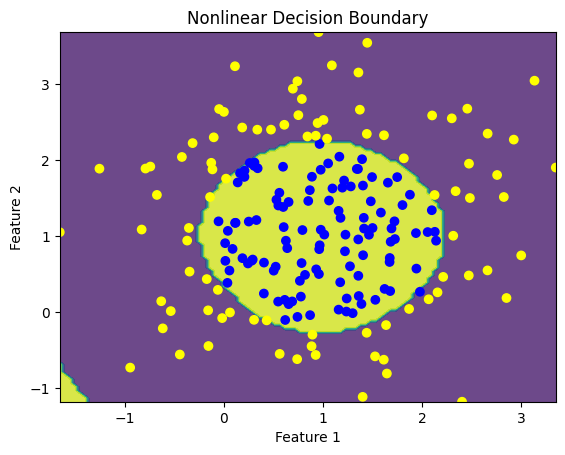

In [171]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc


# Create polynomial features (nonlinear transformation)
poly = PolynomialFeatures(degree=5)  # You can adjust the degree

X_train, X_test, y_train, y_test = train_test_split(X_sampled, y_sampled, test_size=0.2, random_state=1234)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Initialize and fit the logistic regression model
model = LogisticRegression(solver='lbfgs')  # You can choose other solvers
model.fit(X_train_poly, y_train)

# Predictions on test set
y_pred = model.predict(X_test_poly)

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Compute ROC curve and AUC
y_prob = model.predict_proba(X_test_poly)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

print("\nDecision Boundary plot:")
nonlinear_decision_boundary (X_test, y_test,  model, poly)

### Custom Polynomial Logistic Regression model

In [172]:
class Poly_Logistic_Regression:

    def __init__(self, learning_rate= 0.01, convergence_tol=1e-6, rate_decay=None, degree=None):
        # TODO: Initialize class attributes
        self.learning_rate = learning_rate
        self.rate_decay = rate_decay
        self.convergence_tol = convergence_tol
        self.W = None
        self.degree = degree

        if self.degree and self.degree > 0:
            self.polynomial = PolynomialFeatures(degree=self.degree, include_bias=False) #TODO: If degree is valid, initialize PolynomialFeatures transformer with the specified degree and exclude bias=False
        else:
            # If degree is 0 or None, skip polynomial expansion.
            self.polynomial = None

    def initialize_parameters(self, n_features):
        self.W = np.random.randn(n_features) * 0.01 # TODO: Initialize weight vector with small random values for better convergence - multiply random normal values by 0.01 to ensure weights start close to zero

    def preprocess(self, X, fit=True):
        """
        This method reshapes the input `X` if needed, applies polynomial feature transformation (if specified),
        standardizes the features, and adds a bias term (column of 1s).
        It prepares the data for training or prediction.
        """

        if X.ndim == 1:
            X = X.reshape(-1, 1) #  Reshape if input is a 1D array
        if self.polynomial is not None:  #  Check if polynomial expansion is needed
            if fit:
                X = self.polynomial.fit_transform(X) # TODO:  Fit polynomial features to the data
            else:
                X = self.polynomial.transform(X) # TODO:  Transform data using existing polynomial features

        X = (X - np.mean(X, axis=0)) / (np.std(X, axis=0) + 1e-9) # TODO: Standardize features
        X = np.insert(X, 0, 1, axis=1) # TODO: Add bias term (column of ones)
        self.X = X # TODO: Save preprocessed data
        return X

    def forward(self, X):
        z = np.dot(X, self.W)
        return self._sigmoid(z)

    #Sigmoid method (logistic)
    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def compute_cost(self, predictions):
        epsilon = 1e-9
        y1 = self.y * np.log(predictions + epsilon)
        y2 = (1 - self.y) * np.log(1 - predictions + epsilon)
        return -np.mean(y1 + y2)

    def backward(self, predictions):
        n_samples = self.X.shape[0]
        dz = predictions - self.y
        dw = (1/n_samples) * np.dot(self.X.T, dz)
        return dw

    def fit(self, X, y, iterations= 1000, plot_cost=True):
        assert isinstance(X, np.ndarray), "X must be a NumPy array"
        assert isinstance(y, np.ndarray), "y must be a NumPy array"
        assert X.shape[0] == y.shape[0], "X and y must have the same number of samples"
        assert iterations > 0, "Iterations must be greater than 0"

        X = self.preprocess(X, fit=True) # TODO: Preprocess the input data
        self.y = y # TODO: Store target values
        self.initialize_parameters(X.shape[1]) # TODO: Initialize parameters (weights)

        costs = [] # TODO: Create an empty list to store cost history

        initial_lr = self.learning_rate # TODO: Store the initial learning rate for decay calculations

        for i in range(iterations):
            predictions = self.forward(X) # TODO: Calculate predictions using forward propagation
            cost = self.compute_cost(predictions) # TODO: Calculate the cost for the current predictions
            delta_error = self.backward(predictions) # TODO: Calculate the gradients using backward propagation

            # Calculate the learning rate for the current iteration
            if self.rate_decay:
              self.learning_rate =  initial_lr / (1 + self.rate_decay * i) # TODO: Update the learning rate for the current iteration using decay formula
            # Update parameters
            self.W = self.W - self.learning_rate * delta_error # TODO: Update the weights using gradient descent

            costs.append(cost) # TODO: Store the current cost for monitoring

            if i % 100 == 0: # Print after each 100 iterations
                print(f'Iteration: {i}, Cost: {cost}')

            if i > 0 and abs(costs[-1] - costs[-2]) < self.convergence_tol:

                print(f'Converged after {i} iterations.')
                break

        if plot_cost:
            plot_cost_history(costs)

    def predict(self, X):
        X = self.preprocess(X, fit=False) # TODO: Preprocess the input features using the preprocess method
        threshold = 0.5 # TODO: Set the classification threshold (typically 0.5 for binary classification)
        y_predicted = self.forward(X) # TODO: Get probability predictions by passing the preprocessed features through the forward method
        y_predicted_cls = (y_predicted >= threshold).astype(int) # TODO: Convert probabilities to binary class labels (1 if above threshold, 0 otherwise)
        return np.array(y_predicted_cls)

### Testing against Scikit Learn's Polynomial Regression

In [173]:
X_sampled, y_sampled = load_non_liear_data()
X_train, X_test, y_train, y_test = train_test_split(X_sampled, y_sampled, test_size=0.2, random_state=1234)

poly_model = Poly_Logistic_Regression(degree=5, learning_rate=0.1, rate_decay=0.0001)
poly_model.fit(X_train, y_train)

Iteration: 0, Cost: 0.6887017101329207
Iteration: 100, Cost: 0.38457647367183156
Iteration: 200, Cost: 0.30878215139915943
Iteration: 300, Cost: 0.26798023951164135
Iteration: 400, Cost: 0.2413805622513825
Iteration: 500, Cost: 0.22223219690706741
Iteration: 600, Cost: 0.20757939965731198
Iteration: 700, Cost: 0.19589119000171684
Iteration: 800, Cost: 0.18628260617616912
Iteration: 900, Cost: 0.17820077570755202



Confusion Matrix:


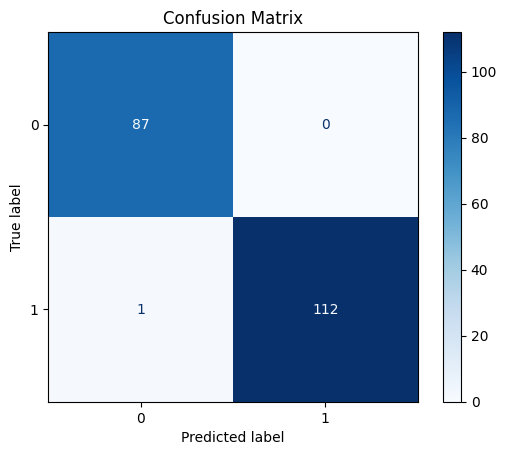


Custom Confusion Matrix:


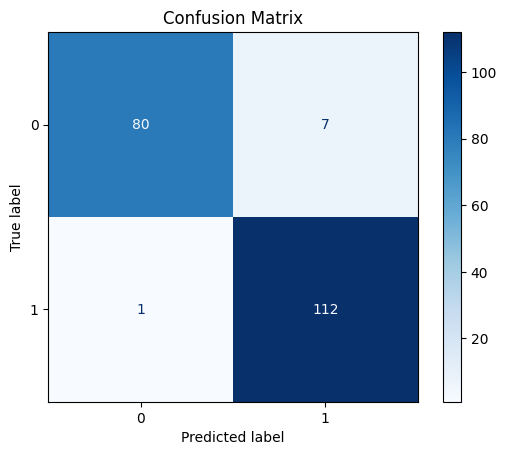

In [174]:
# Predictions on test set
y_pred = model.predict(X_test_poly)
custom_pred = poly_model.predict(X_test)

print("\nConfusion Matrix:")
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

print("\nCustom Confusion Matrix:")
disp2 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, custom_pred))
disp2.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

---
# **PART III: Multi-Class Logistic Regression**
---

## One-vs-All (OvA) Classification

The **One-vs-All** (OvA), also known as **One-vs-Rest (OvR)**, is a popular strategy for extending **binary classification algorithms** (like logistic regression or SVM) to handle **multi-class classification problems**.

###  Concept

In OvA, we break a multi-class classification problem into **multiple binary classification problems**. If there are \( K \) classes, we train:

- **One binary classifier per class**, where:
  - The current class is labeled as **positive (1)**
  - All other classes are labeled as **negative (0)**

So, each classifier learns to **distinguish one class** from all the others.

###  How It Works

For each new input sample:
1. The sample is passed to **all K classifiers**
2. Each classifier outputs a **score or probability**
3. The class whose classifier gives the **highest score** is selected as the prediction

###  Example

Suppose we want to classify flowers into 3 classes:
- Setosa
- Versicolor
- Virginica

OvA will train 3 models:
- Model 1: Setosa vs not Setosa
- Model 2: Versicolor vs not Versicolor
- Model 3: Virginica vs not Virginica

Then, for a new flower, all 3 models are applied, and the class with the highest score is selected.

###  Advantages
- Simple and easy to implement
- Can reuse any **binary classification algorithm**

###  Disadvantages
- Classifiers are trained **independently**
- May result in **conflicting predictions** or **poor calibration** if class distributions are unbalanced




### **Imports**

In [175]:
from sklearn import datasets
from sklearn.preprocessing import scale
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

### **Loading the data**

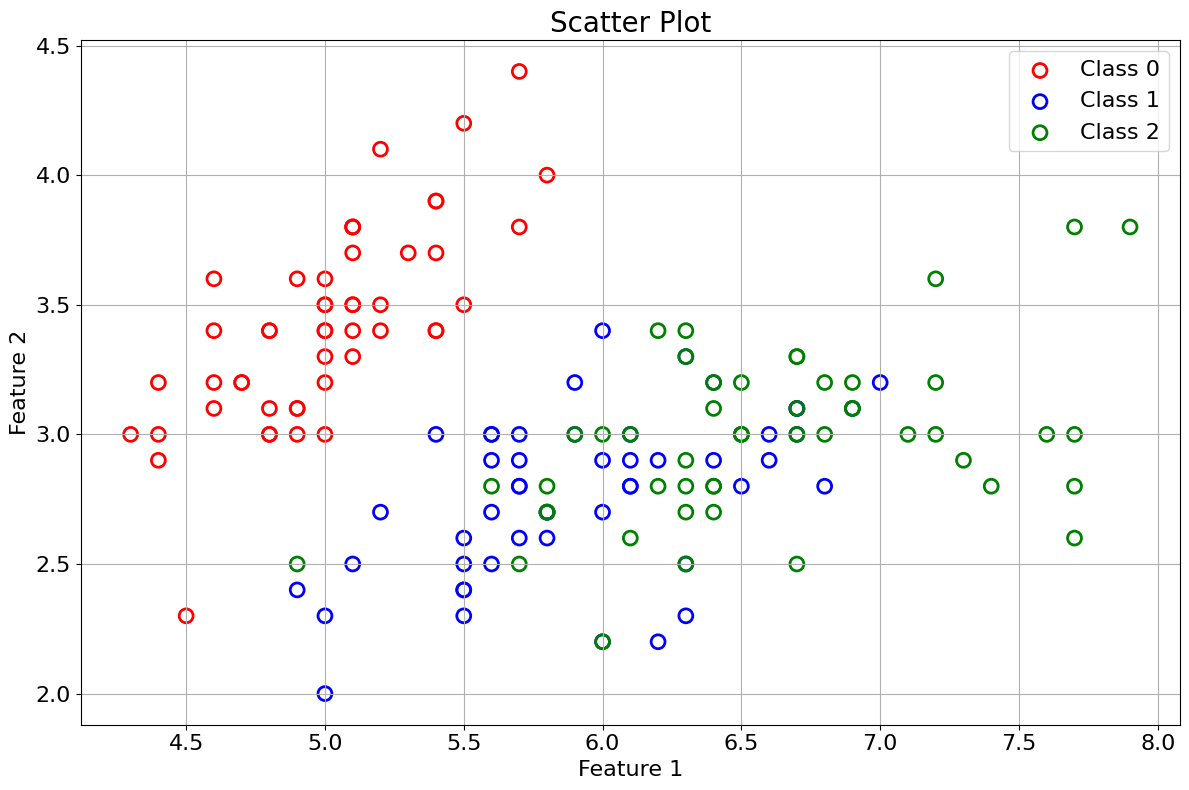

In [176]:
# Load the Iris dataset
iris = datasets.load_iris()
df = pd.DataFrame(iris.data)
X = iris.data[:, :2]  # we only take the first two features.
y = iris.target

plot_scatter(X, y)

### **Splitting**

In [177]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 5)
print (X_train.shape, "--", y_train.shape, "\n", X_test.shape, "--", y_test.shape)
np.unique_counts(y)

(112, 2) -- (112,) 
 (38, 2) -- (38,)


UniqueCountsResult(values=array([0, 1, 2]), counts=array([50, 50, 50]))

### **One vs All Classifier**

In [178]:
from sklearn.base import BaseEstimator, ClassifierMixin
class OneVall_classifier(BaseEstimator, ClassifierMixin):
  def __init__(self):
      self.classifiers = [] # TODO: Initialize an empty list to store individual binary classifiers
      self.is_fitted_ = False # Initialize a flag to track if the model has been fitted

  def fit(self, X, y):
      X_scaled = (X - np.mean(X, axis=0)) / (np.std(X, axis=0) + 1e-9) # TODO: Standardize input features
      for i in range(len(np.unique(y))):
        # Create binary labels for the current class
        binary_y = (y == np.unique(y)[i]).astype(int) # TODO: Create binary labels for the current class (1 for current class, 0 for all others)
        print ("i==", i, " \n binary_y_train=", binary_y)

        # Train a logistic regression classifier
        clf = LogisticRegression(solver='lbfgs')
        clf.fit(X_scaled, binary_y) # TODO: Train the classifier on standardized features and binary labels

        self.classifiers.append(clf) # TODO: Add the trained classifier to the classifiers list
       # Mark the model as fitted
      self.is_fitted_ = True # TODO: Mark the model as fitted
      return self

  def predict(self, X):
      if X.ndim == 1:
        X = X.reshape(-1, 1) # TODO: Reshape X to 2D array if it's 1D

      X = (X - np.mean(X, axis=0)) / (np.std(X, axis=0) + 1e-9) # TODO: Standardize the input features
      # Compute prediction probability for each class

      probabilities = [
          clf.predict_proba(X)[:, 1] for clf in self.classifiers
      ]

      mx = np.argmax(probabilities, axis=0) # TODO: Return the class index with the highest probability for each sample

      return mx

  def score(self, X, y):
      y_pred = self.predict(X) # TODO: Generate predictions
      return np.mean(y_pred == y) # TODO: Calculate and return the accuracy score by comparing predictions to true labels


### **Fit and make predictions**

In [179]:
lr_OvA = OneVall_classifier()
lr_OvA.fit(X, y)

lr_OvA.score(X, y)
predictions_OvA = lr_OvA.predict(X_test)
report = classification_report(y_test, predictions_OvA)
print(f"Classification Report :\n{report}\n")

i== 0  
 binary_y_train= [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]
i== 1  
 binary_y_train= [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]
i== 2  
 binary_y_train= [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1]
Classif

### **Testing against Scikit Learn's OneVsRestClassifier**

In [180]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

logistic_regression_multinomial = LogisticRegression().fit(X, y)
logistic_regression_ovr = OneVsRestClassifier(LogisticRegression()).fit(X, y)
lr_OvA = OneVall_classifier().fit(X, y)

accuracy_multinomial = logistic_regression_multinomial.score(X, y)
accuracy_ovr = logistic_regression_ovr.score(X, y)
accuracy_OvA = lr_OvA.score(X, y)
accuracy_OvA

i== 0  
 binary_y_train= [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]
i== 1  
 binary_y_train= [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]
i== 2  
 binary_y_train= [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1]


np.float64(0.7933333333333333)

### **Plotting the decision boundaries**

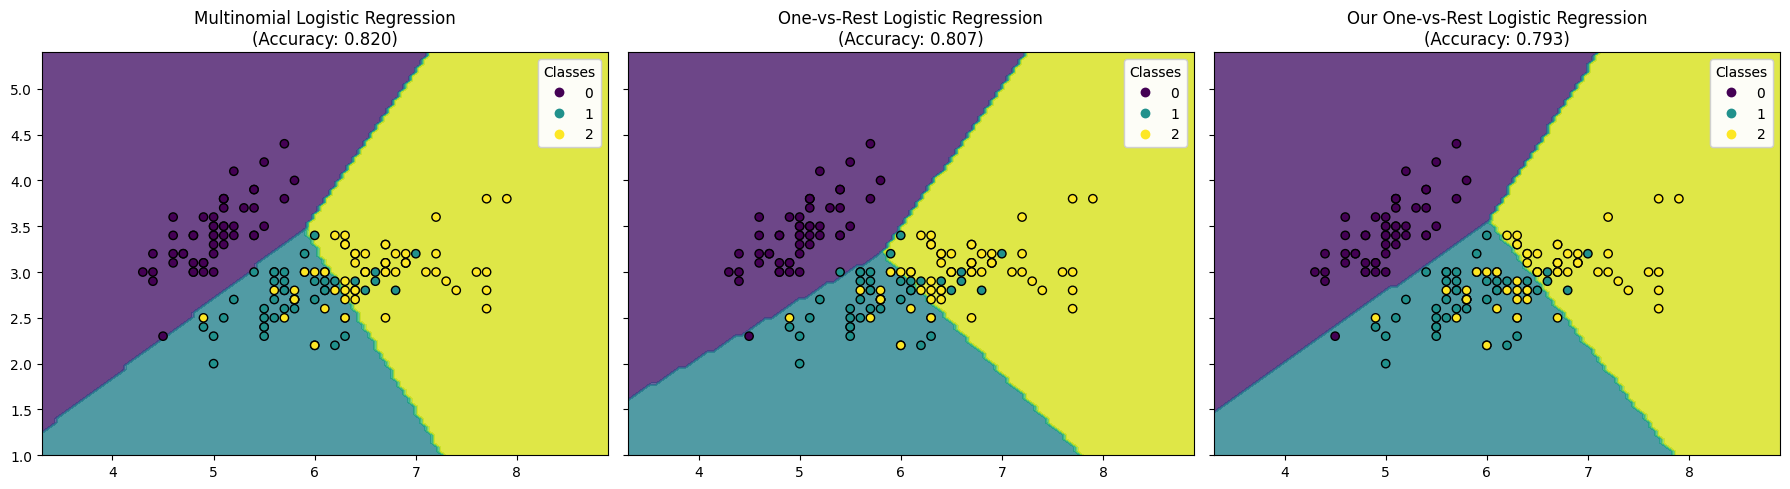

In [181]:
from sklearn.inspection import DecisionBoundaryDisplay

# Create a 1x3 grid of subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# List the three models with their titles and assign each to a different subplot
for model, title, ax in [
    (
        logistic_regression_multinomial,
        f"Multinomial Logistic Regression\n(Accuracy: {accuracy_multinomial:.3f})",
        ax1,
    ),
    (
        logistic_regression_ovr,
        f"One-vs-Rest Logistic Regression\n(Accuracy: {accuracy_ovr:.3f})",
        ax2,
    ),
    (
        lr_OvA,
        f"Our One-vs-Rest Logistic Regression\n(Accuracy: {accuracy_OvA:.3f})",
        ax3,
    ),
]:
    DecisionBoundaryDisplay.from_estimator(
        model,
        X,
        ax=ax,
        response_method="predict",
        alpha=0.8,
    )
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
    legend = ax.legend(*scatter.legend_elements(), title="Classes")
    ax.add_artist(legend)
    ax.set_title(title)

plt.tight_layout()
plt.show()

## **Extra Task:** Self Evaluation

> In the previous sections, specifically in our **OneVall Classifier**, you noticed that we employed **scikit-learn's Logistic Regression** as our independent classifier for each class.

---
> **In the code cell below, you are tasked with modifying the classifier to use a from-scratch implementation of logistic regression—including its methods for forward, backward, sigmoid function, etc.**
---

> **How long did it take you to complete this task?.**


### **Useful Refs**

> - [Another way to implement Multinomial Logistic Regression from Scratch](https://www.kaggle.com/code/vitorgamalemos/multinomial-logistic-regression-from-scratch)
> - [3D plots of decision boundaries](https://www.kaggle.com/code/frankmollard/3d-decision-boundaries)